# LISS-IV Cloud Removal GAN - Automated Patch Dataset Generation Pipeline

This notebook processes raw LISS-IV satellite ZIP files, extracts Band 2 (Green), Band 3 (Red), and Band 4 (NIR), normalizes pixel intensities, extracts valid 256x256 clear patches, generates paired synthetic cloudy patches, and saves them as `.npy` array files for training Pix2Pix cGAN models.

In [1]:
import os
import zipfile
import shutil
import glob
from pathlib import Path
import rasterio
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Dataset directories
RAW_ZIPS_DIR = Path("Data/raw_Zips")
TEMP_EXTRACT_DIR = Path("temp_extract")
CLEAR_DIR = Path("Data/Clear_Patches")
CLOUDY_DIR = Path("Data/Cloudy_Patches")

# Create output directories
CLEAR_DIR.mkdir(parents=True, exist_ok=True)
CLOUDY_DIR.mkdir(parents=True, exist_ok=True)
TEMP_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Patch Extraction Settings
PATCH_SIZE = 256
STRIDE = 128  # 50% overlap for dataset generation
VALID_THRESHOLD = 0.90  # At least 90% non-zero valid pixels per patch
SCALE = 1  # Native 5.8m spatial resolution

print("Pipeline initialized.")
print(f"Zip directory: {RAW_ZIPS_DIR.resolve()}")
print(f"Clear patches destination: {CLEAR_DIR.resolve()}")
print(f"Cloudy patches destination: {CLOUDY_DIR.resolve()}")

Pipeline initialized.
Zip directory: C:\Projects\Major-project\LISS-IV-Cloud-Removal-GAN\Data\Raw_Zips
Clear patches destination: C:\Projects\Major-project\LISS-IV-Cloud-Removal-GAN\Data\Clear_Patches
Cloudy patches destination: C:\Projects\Major-project\LISS-IV-Cloud-Removal-GAN\Data\Cloudy_Patches


In [2]:
def enhance_band(path, scale=1):
    """
    Reads raster band, applies 2%-98% percentile linear stretch and normalizes to [0, 1].
    """
    with rasterio.open(path) as src:
        band = src.read(
            1,
            out_shape=(src.height // scale, src.width // scale),
            resampling=rasterio.enums.Resampling.bilinear
        ).astype(np.float32)
        
    valid_mask = band > 0
    if not np.any(valid_mask):
        return band
        
    p2 = np.percentile(band[valid_mask], 2)
    p98 = np.percentile(band[valid_mask], 98)
    
    if p98 > p2:
        band = (band - p2) / (p98 - p2)
        band = np.clip(band, 0, 1)
    else:
        band = np.zeros_like(band)
        
    band[~valid_mask] = 0
    return band

def add_synthetic_clouds(clean_patch):
    """
    Adds multi-scale synthetic cloud noise with realistic smooth opacity and band-dependent brightness boost.
    clean_patch shape: (3, H, W) [B2, B3, B4] in range [0, 1]
    """
    c, h, w = clean_patch.shape
    
    # Low-resolution noise grid interpolated via bi-cubic scaling
    low_res_h, low_res_w = 32, 32
    noise = np.random.uniform(0, 1, (low_res_h, low_res_w)).astype(np.float32)
    cloud_mask = cv2.resize(noise, (w, h), interpolation=cv2.INTER_CUBIC)
    
    # Soft blur for realistic cloud gradients
    cloud_mask = cv2.GaussianBlur(cloud_mask, (21, 21), 0)
    
    # Normalize mask to [0, 1]
    c_min, c_max = cloud_mask.min(), cloud_mask.max()
    if c_max > c_min:
        cloud_mask = (cloud_mask - c_min) / (c_max - c_min)
        
    # Non-linear opacity curve
    cloud_mask = np.power(cloud_mask, 1.5)
    
    # Random max alpha opacity density
    max_alpha = np.random.uniform(0.35, 0.85)
    alpha = cloud_mask * max_alpha
    alpha = np.expand_dims(alpha, axis=0) # shape (1, H, W)
    
    # Natural cloud scattered reflection per band
    cloud_color = np.array([
        np.random.uniform(0.75, 0.95),  # B2 (Green)
        np.random.uniform(0.75, 0.95),  # B3 (Red)
        np.random.uniform(0.65, 0.85)   # B4 (NIR)
    ], dtype=np.float32)[:, None, None]
    
    # Alpha blending: Cloudy = (1 - alpha) * Clean + alpha * CloudColor
    cloudy_patch = (1.0 - alpha) * clean_patch + alpha * cloud_color
    return np.clip(cloudy_patch, 0, 1)

print("Preprocessing and cloud augmentation functions loaded successfully.")

Preprocessing and cloud augmentation functions loaded successfully.


In [3]:
# Search for raw ZIP files
zip_files = list(RAW_ZIPS_DIR.glob("*.zip"))
if not zip_files:
    # Fallback to searching anywhere in Data/
    zip_files = list(Path("Data").rglob("*.zip"))

print(f"Found {len(zip_files)} raw ZIP scenes for processing.")

total_valid_pairs = 0
total_skipped_patches = 0

for zip_idx, zip_file in enumerate(zip_files, 1):
    print(f"\n[{zip_idx}/{len(zip_files)}] Processing Scene: {zip_file.name}")
    
    # Clear temp extraction directory
    if TEMP_EXTRACT_DIR.exists():
        shutil.rmtree(TEMP_EXTRACT_DIR)
    TEMP_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    
    # Unzip scene
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(TEMP_EXTRACT_DIR)
        
    # Locate B2, B3, B4 TIFF files
    tif_files = list(TEMP_EXTRACT_DIR.rglob("*.tif")) + list(TEMP_EXTRACT_DIR.rglob("*.tiff"))
    band_paths = {}
    for tif in tif_files:
        fname = tif.name.upper()
        if "BAND2" in fname or "_B2" in fname or "BAND_2" in fname:
            band_paths["B2"] = tif
        elif "BAND3" in fname or "_B3" in fname or "BAND_3" in fname:
            band_paths["B3"] = tif
        elif "BAND4" in fname or "_B4" in fname or "BAND_4" in fname:
            band_paths["B4"] = tif
            
    if not ("B2" in band_paths and "B3" in band_paths and "B4" in band_paths):
        print(f"   [Warning] Missing standard bands in {zip_file.name}. Found: {list(band_paths.keys())}. Skipping scene.")
        continue
        
    # Enhance/read bands
    b2_img = enhance_band(band_paths["B2"], scale=SCALE)
    b3_img = enhance_band(band_paths["B3"], scale=SCALE)
    b4_img = enhance_band(band_paths["B4"], scale=SCALE)
    
    h, w = b2_img.shape
    scene_valid_count = 0
    scene_skip_count = 0
    
    # Sliding window patch extraction
    for row in range(0, h - PATCH_SIZE + 1, STRIDE):
        for col in range(0, w - PATCH_SIZE + 1, STRIDE):
            patch_b2 = b2_img[row:row+PATCH_SIZE, col:col+PATCH_SIZE]
            patch_b3 = b3_img[row:row+PATCH_SIZE, col:col+PATCH_SIZE]
            patch_b4 = b4_img[row:row+PATCH_SIZE, col:col+PATCH_SIZE]
            
            # Check valid non-zero mask across all 3 bands
            valid_pixels = (patch_b2 > 0) & (patch_b3 > 0) & (patch_b4 > 0)
            valid_frac = valid_pixels.mean()
            
            # Filter out black border regions or oversaturated patches
            if valid_frac < VALID_THRESHOLD or patch_b2.max() == patch_b2.min():
                scene_skip_count += 1
                continue
                
            # Stack clear patch: shape (3, 256, 256) -> [B2, B3, B4]
            clear_patch = np.stack([patch_b2, patch_b3, patch_b4], axis=0).astype(np.float32)
            
            # Generate synthetic cloudy patch
            cloudy_patch = add_synthetic_clouds(clear_patch)
            
            # Save array files
            file_id = f"patch_{total_valid_pairs:05d}.npy"
            np.save(CLEAR_DIR / file_id, clear_patch)
            np.save(CLOUDY_DIR / file_id, cloudy_patch)
            
            total_valid_pairs += 1
            scene_valid_count += 1
            
    print(f"   Saved {scene_valid_count} valid patch pairs. (Skipped {scene_skip_count} border/empty patches)")

# Clean up temp files
if TEMP_EXTRACT_DIR.exists():
    shutil.rmtree(TEMP_EXTRACT_DIR)

print("\n" + "="*50)
print(f" Processing Complete! Total valid patch pairs generated: {total_valid_pairs}")
print("="*50)

Found 5 raw ZIP scenes for processing.

[1/5] Processing Scene: R2F11NOV2023065188011200053SSANSTUC00GTDC.zip
   Saved 12112 valid patch pairs. (Skipped 5808 border/empty patches)

[2/5] Processing Scene: R2F13SEP2024069550011100053SSANSTUC00GTDB.zip
   Saved 11751 valid patch pairs. (Skipped 6156 border/empty patches)

[3/5] Processing Scene: R2F16JAN2025071326011200053SSANSTUC00GTDA.zip
   Saved 11494 valid patch pairs. (Skipped 6298 border/empty patches)

[4/5] Processing Scene: R2F29NOV2024070644011200053SSANSTUC00GTDC.zip
   Saved 11987 valid patch pairs. (Skipped 5933 border/empty patches)

[5/5] Processing Scene: R2F30NOV2023065458011100053SSANSTUC00GTDB.zip
   Saved 11623 valid patch pairs. (Skipped 6425 border/empty patches)

 Processing Complete! Total valid patch pairs generated: 58967


## Dataset Sample Visualization
Visualize paired Clear (Ground Truth) vs Synthetic Cloudy Patches extracted from LISS-IV scenes.

Total clear patches in directory: 58967
Total cloudy patches in directory: 58967


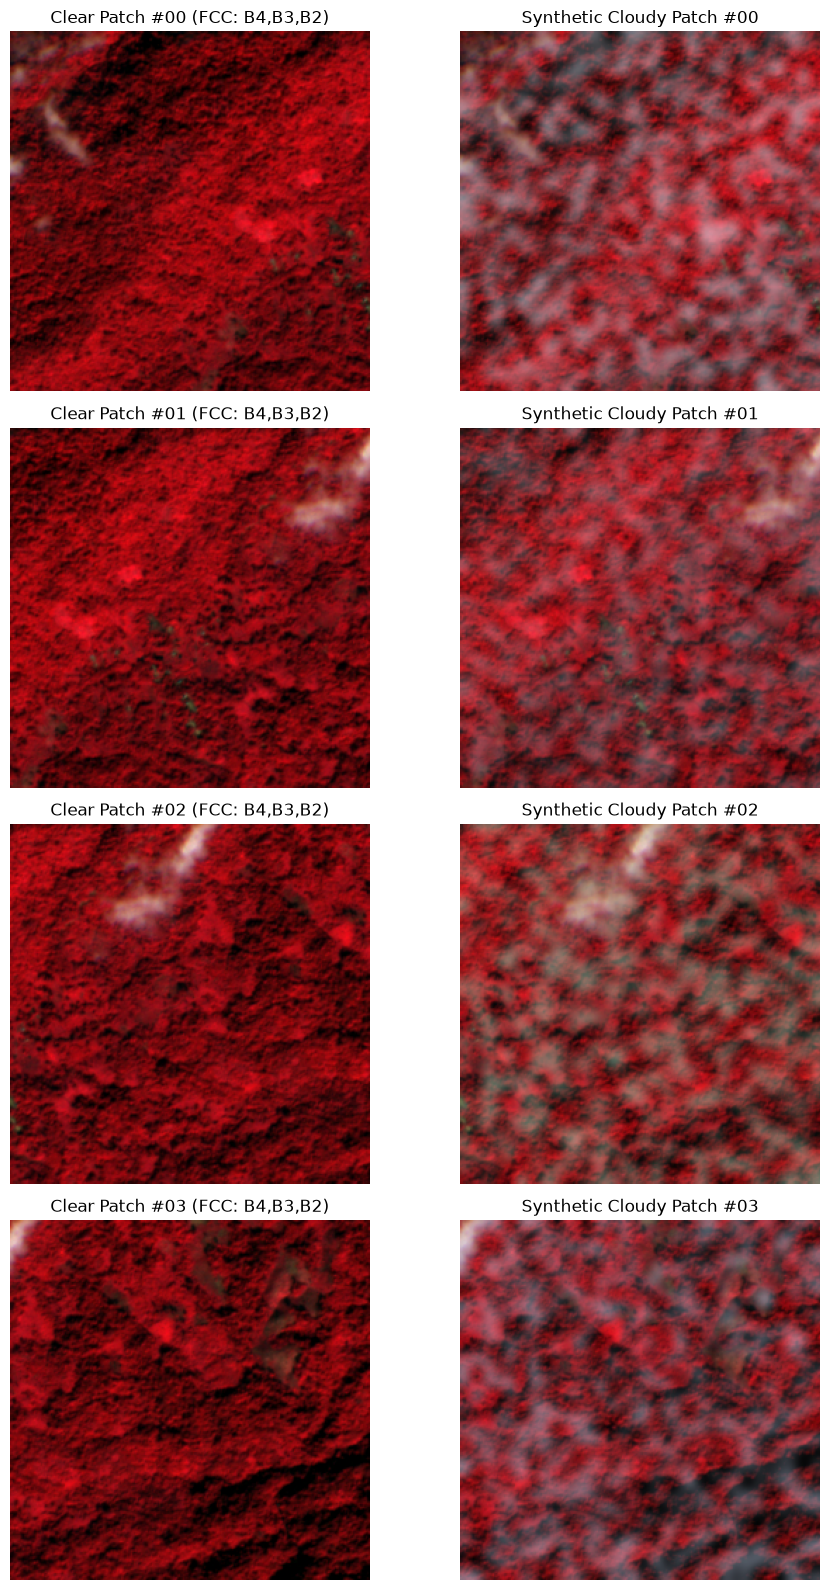

In [4]:
clear_files = sorted(list(CLEAR_DIR.glob("*.npy")))
cloudy_files = sorted(list(CLOUDY_DIR.glob("*.npy")))

print(f"Total clear patches in directory: {len(clear_files)}")
print(f"Total cloudy patches in directory: {len(cloudy_files)}")

if clear_files:
    num_samples = min(4, len(clear_files))
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i in range(num_samples):
        clear_p = np.load(clear_files[i])
        cloudy_p = np.load(cloudy_files[i])
        
        # False Color Composite (FCC: B4, B3, B2) -> (R, G, B)
        clear_fcc = np.stack([clear_p[2], clear_p[1], clear_p[0]], axis=-1)
        cloudy_fcc = np.stack([cloudy_p[2], cloudy_p[1], cloudy_p[0]], axis=-1)
        
        axes[i, 0].imshow(clear_fcc)
        axes[i, 0].set_title(f"Clear Patch #{i:02d} (FCC: B4,B3,B2)")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(cloudy_fcc)
        axes[i, 1].set_title(f"Synthetic Cloudy Patch #{i:02d}")
        axes[i, 1].axis("off")
        
    plt.tight_layout()
    plt.show()
else:
    print("No patches found to visualize. Run the processing cell above.")